In [1]:
# Installing dependencies
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import torchvision
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import csv
import cv2
import math
import matplotlib.pyplot as plt
import re
from collections import Counter
import os
import medmnist
from medmnist import INFO, Evaluator
from typing import Dict, Tuple, List, Optional
from pathlib import Path
from collections import defaultdict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from tqdm import tqdm # for the progress bar
import time
import pandas as pd
import copy
import math

In [2]:
data_flag = 'bloodmnist'
download = True 
# establishing what mednist dataset i'm using

In [3]:
num_epochs = 100
batch_size = 64
lr = 0.0005
# defining training info

In [4]:
info = INFO[data_flag] # gets me the info of the dataset
task = info['task']
num_classes = len(info['label']) # how many classes
print(info)
DataClass = getattr(medmnist, info['python_class'])

{'python_class': 'BloodMNIST', 'description': 'The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.', 'url': 'https://zenodo.org/records/10519652/files/bloodmnist.npz?download=1', 'MD5': '7053d0359d879ad8a5505303e11de1dc', 'url_64': 'https://zenodo.org/records/10519652/files/bloodmnist_64.npz?download=1', 'MD5_64': '2b94928a2ae4916078ca51e05b6b800b', 'url_128': 'https://zenodo.org/records/10519652/files/bloodmnist_128.npz?download=1', 'MD5_128': 'adace1e0ed228fccda1f39692059dd4c', 'url_224': 'https://zenodo.org/records/10519652/files/bloodmnist_224.npz

In [5]:
device = torch.device('mps' if torch.mps.is_available else 'cpu')
print(device)
# establishing what device i will be working on; my local machine a mac

mps


In [6]:
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], # standard for medmnist datasets
                         std=[0.5]),
    
    # adding some augmentations
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
    
    # already center cropped and resized
])
# transforming the important bits of data

In [7]:
class_names = [
    'Basophil',
    'Eosinophil',
    'Erythroblast',
    'Immature Granulocytes',
    'Lymphocyte',
    'Monocyte', 
    'Neutrophil',
    'Platelet'
]
print(f"Number of class names: {len(class_names)}")

Number of class names: 8


In [8]:
# separate the datasets by train, validation, and test
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

In [9]:
# see info for each specific split of the dataset
print(train_dataset)
print('=' * 50)
print(test_dataset)
print('=' * 50)
print(val_dataset)

Dataset BloodMNIST of size 28 (bloodmnist)
    Number of datapoints: 11959
    Root location: /Users/mikayla/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
    Number of samples: {'train': 11959, 'val': 1712, 'test': 3421}
    Description: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
    Lice

In [10]:
# extract labels from each dataset
train_labels = train_dataset.labels.flatten()
val_labels = val_dataset.labels.flatten()
test_labels = test_dataset.labels.flatten()

# get class names
class_names_dict = info.get('label', {})
num_classes = 8
print(class_names_dict)

{'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}


In [11]:
def analyze_class_distributions(labels, split_name):
    class_counts = Counter(labels)
    total_samples = len(labels)
    print(f"{split_name} set class distribution:")
    print("class | count | percentage")
    print('=' * 50)
    
    for class_idx in sorted(class_counts.keys()):
        count = class_counts[class_idx]
        percentage = (count / total_samples) * 100
        class_name = class_names_dict.get(str(class_idx), f"class {class_idx}")
        print(f"{class_idx:5d} | {count:5d} | {percentage:6.2f}%")
    return class_counts
    
# analyze each split
train_counts = analyze_class_distributions(train_labels, 'training')
val_counts = analyze_class_distributions(val_labels, 'validation')
test_counts = analyze_class_distributions(test_labels, 'testing')

training set class distribution:
class | count | percentage
    0 |   852 |   7.12%
    1 |  2181 |  18.24%
    2 |  1085 |   9.07%
    3 |  2026 |  16.94%
    4 |   849 |   7.10%
    5 |   993 |   8.30%
    6 |  2330 |  19.48%
    7 |  1643 |  13.74%
validation set class distribution:
class | count | percentage
    0 |   122 |   7.13%
    1 |   312 |  18.22%
    2 |   155 |   9.05%
    3 |   290 |  16.94%
    4 |   122 |   7.13%
    5 |   143 |   8.35%
    6 |   333 |  19.45%
    7 |   235 |  13.73%
testing set class distribution:
class | count | percentage
    0 |   244 |   7.13%
    1 |   624 |  18.24%
    2 |   311 |   9.09%
    3 |   579 |  16.92%
    4 |   243 |   7.10%
    5 |   284 |   8.30%
    6 |   666 |  19.47%
    7 |   470 |  13.74%


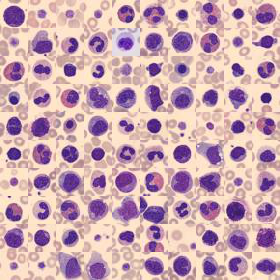

In [12]:
# see a 10x10 grid of images
train_dataset.montage(length=10)

In [13]:
# defining the architecture of the model, using ResNet18 and adding some changes
class ConvNet(nn.Module):
    def __init__(self, dropout_rate = 0.5):
        super(ConvNet, self).__init__()
        self.resnet = torchvision.models.resnet18(weights='IMAGENET1K_V1')
        
        # experimenting with freezing layers
        for param in self.resnet.layer1.parameters():
            param.requires_grad = False
        
        for param in self.resnet.layer2.parameters():
            param.requires_grad = False
        
        for param in self.resnet.layer3.parameters():
            param.requires_grad = True
        
        for param in self.resnet.layer4.parameters():
            param.requires_grad = True
            
        self.resnet.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 8)
            # this will produce the logits; only use activation functions in hidden layers
        )
        
    def forward(self, x):
        return self.resnet(x)

In [14]:
# defining the class to train and track metrics
class TrainingMetrics:
    def __init__(self):
        self.reset()
        
    def reset(self):
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []
        self.lrs = []
        self.epoch_times = []
        
    def update(self, train_loss, val_loss, train_acc, val_acc, lr, epoch_time):
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)
        self.train_accs.append(train_acc)
        self.val_accs.append(val_acc)
        self.lrs.append(lr)
        self.epoch_times.append(epoch_time)
        

In [15]:
class FocalLoss(nn.Module):
    def __init__(self, alpha = None, gamma = 2, reduction = 'mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        if self.alpha is not None: 
            if self.alpha.type() != inputs.data.type():
                self.alpha = self.alpha.type_as(inputs.data)
            at = self.alpha.gather(0, targets.data.view(-1))
            focal_loss = at * focal_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss
        
def calculate_class_weights_smooth(class_counts = [852, 2181, 1085, 2026, 849, 993, 2330, 1643]):
    total = sum(class_counts)
    # calculate inverse frequency first
    inv_freq = [total / count for count in class_counts]
    # take square root to soften the weights
    weights = [math.sqrt(w) for w in inv_freq]
    # normalize so average weight is 1
    avg_weight = sum(weights) / len(weights)
    weights = [w / avg_weight for w in weights]
    return torch.FloatTensor(weights)

# adding to boost weaker classes
def calculate_targeted_weights(class_counts):
    base_weights = [max(class_counts) / count for count in class_counts]
    
    boost_factors = [2.5, # adding each number based on per-class accuracy of previous training cycle
                     1.0,
                     1.5,
                     2.5,
                     1.0,
                     2.0,
                     0.8,
                     0.6]
    
    raw_weights = [w * boost for w, boost in zip(base_weights, boost_factors)] 
    clamped_weights = [min(max(w, 0.8), 2.5) for w in raw_weights] # clamp weights to avoid extremes
    return torch.FloatTensor(clamped_weights)

class_counts = [852, 2181, 1085, 2026, 849, 993, 2330, 1643]
alpha = calculate_targeted_weights(class_counts)

In [16]:
def create_sampling_weights(dataset_targets, class_weights):
    # Convert to tensor with proper dtype
    targets_tensor = torch.tensor(dataset_targets, dtype=torch.long)
    
    # Ensure targets are within valid range
    if targets_tensor.max() >= len(class_weights):
        raise ValueError(f"Target values go up to {targets_tensor.max()} but only {len(class_weights)} classes in class_weights")
    
    sample_weights = class_weights[targets_tensor]
    return sample_weights

class_weights = calculate_targeted_weights(class_counts)
train_targets = train_dataset.labels.flatten()
sample_weights = create_sampling_weights(train_targets, class_weights).cpu()

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples = len(sample_weights),
    replacement=True
)

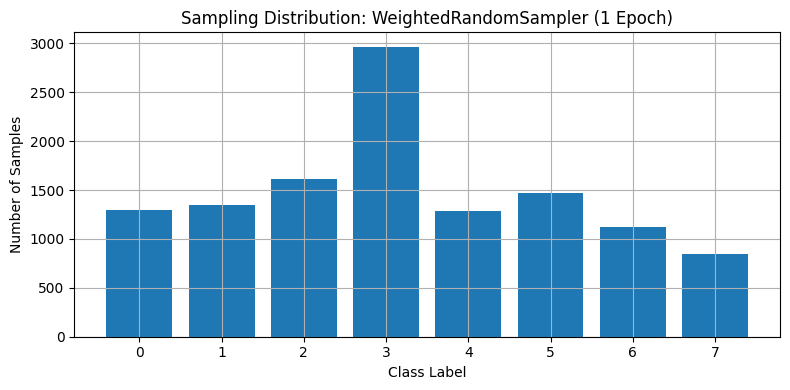

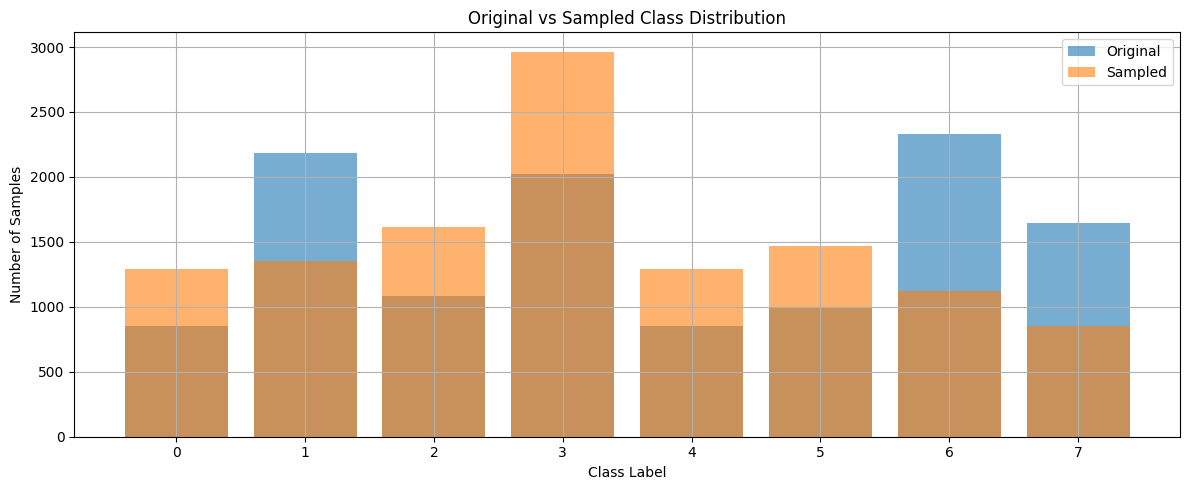

In [17]:
# visualizing sampling distribution
# first simulate one epoch from the sampler
sampled_indices = list(weighted_sampler)
sampled_labels = [train_dataset.labels[i].item() for i in sampled_indices]
sampled_counts = Counter(sampled_labels)
sorted_counts = [sampled_counts[i] for i in range(len(sampled_counts))]

# plot sampling distribution and compare to og class distribution
plt.figure(figsize=(8, 4))
plt.bar(range(len(sorted_counts)), sorted_counts, tick_label=range(len(sorted_counts)))
plt.title("Sampling Distribution: WeightedRandomSampler (1 Epoch)")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.tight_layout()
plt.show()

labels = train_dataset.labels
if labels.ndim > 1:
    # If 2D, flatten it
    original_counts = Counter(labels.flatten())
else:
    # If 1D but each element is an array
    original_counts = Counter([label.item() if hasattr(label, 'item') else label for label in labels])
orig_sorted = [original_counts[i] for i in range(len(original_counts))]

plt.figure(figsize=(12, 5))
plt.bar(range(len(orig_sorted)), orig_sorted, alpha=0.6, label='Original')
plt.bar(range(len(sorted_counts)), sorted_counts, alpha=0.6, label='Sampled')
plt.title("Original vs Sampled Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=False, sampler=weighted_sampler, num_workers=2, drop_last=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [19]:
print(f"Train batch size: {train_loader.batch_size}")
print(f"Val batch size: {val_loader.batch_size}")
print(f"Train dataset size: {len(train_loader.dataset)}")
print(f"Val dataset size: {len(val_loader.dataset)}")

Train batch size: 64
Val batch size: 64
Train dataset size: 11959
Val dataset size: 1712


In [20]:
model = ConvNet()
criterion = FocalLoss(alpha=alpha, gamma = 2) 
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5) # ensures the model trains effectively

In [21]:
model.to(device) # moves the model architecture to the device to be trained

ConvNet(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runn

In [22]:
class EarlyStopping():
    def __init__(self, patience = 10, min_delta = 0.005, restore_best_weights = True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = True
        self.best_model = None
        self.best_loss = None
        self.counter = 0
        self.status = ""
        
    def __call__(self, model, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
        elif self.best_loss - val_loss >= self.min_delta:
            self.best_model = copy.deepcopy(model.state_dict())
            self.best_loss = val_loss
            self.counter = 0
            self.status = f"Improvement found, counter reset to {self.counter}"
        else: 
            self.counter += 1
            self.status = f"No improvement in the last {self.counter} epochs"
            if self.counter >= self.patience:
                self.status = f"Early stopping triggered after {self.counter} epochs"
                if self.restore_best_weights:
                    model.load_state_dict(self.best_model)
                return True
        return False

In [23]:
def train_one_epoch(model, train_loader, criterion, optimizer, device, epoch_num, num_epochs):
    model.train() # puts model in training mode
    running_loss = 0.0
    correct = 0
    total_samples = 0
    batch_losses = []
    
    # creates the progress bar
    pbar = tqdm(train_loader, desc=f'Epoch {epoch_num+1} / {num_epochs} [TRAIN]')
    
    # quick note: enumerate adds a counter to an iterable.
    # lets us know what batch we're on using the batch_idx
    for batch_idx, (data, targets) in enumerate(pbar):
        data, targets = data.to(device), targets.to(device)
        
        # debugging the targets tensor shape error
        targets = targets.squeeze(1)
    
    # zero gradients 
    optimizer.zero_grad()
    
    # forward pass
    outputs = model(data)

    
    # calculating loss
    loss = criterion(outputs, targets)
    
    # backward pass
    loss.backward()
    optimizer.step()
    
    # statistics 
    running_loss += loss.item() # takes the loss from a tensor to a float and then will add each batches' loss up
    batch_losses.append(loss.item())
    
    # calculate accuracy
    _, predicted = torch.max(outputs.data, 1) # this gets the predicted class to then compare it to the actual class.
    total_samples += targets.size(0) # calculates all samples in the epoch from each batch
    correct += (predicted == targets).sum().item()
    
    # update the progress bar
    current_acc = 100. * correct / total_samples
    pbar.set_postfix({
        'Loss': f'{running_loss / (batch_idx + 1):.4f}',
        'Acc': f"{current_acc:.2f}%"
    })
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total_samples
    return epoch_loss, epoch_acc, batch_losses

In [24]:
def evaluate(model, val_loader, criterion, device, epoch_num, num_epochs, mode='VAL'):
    model.eval() # puts model in evaluation mode
    
    running_loss = 0.0
    correct = 0
    total_samples = 0
    all_predictions = []
    all_targets = []
    class_correct = defaultdict(int)
    class_total = defaultdict(int)
    
    # create progress bar
    pbar = tqdm(val_loader, desc=f'Epoch {epoch_num+1}/{num_epochs} [{mode}]')

    with torch.no_grad(): # parameters that were frozen
        for data, targets in pbar:
            data, targets = data.to(device), targets.to(device)
            
            # fixing the targets tensor shape
            targets = targets.squeeze(1)
            
            # forward pass
            outputs = model(data)
            loss = criterion(outputs, targets)
            
            # statistics
            running_loss += loss.item()
            
            # get predictions
            _, predicted = torch.max(outputs, 1)
            total_samples += targets.size(0)
            correct += (predicted == targets).sum().item()
            
            # store predictions and targets for analysis 
            all_predictions.extend(predicted.cpu().numpy()) # numpy requires cpu
            all_targets.extend(targets.cpu().numpy())
            
            # calculate per-class accuracy
            for i in range(targets.size(0)):
                label = targets[i].item()
                class_total[label] += 1
                if predicted[i] == targets[i]:
                    class_correct[label] += 1
            
            # update progess bar
            current_acc = 100. * correct / total_samples
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{current_acc:.2f}%'
            })
            
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total_samples
            
    return epoch_loss, epoch_acc, all_predictions, all_targets, class_correct, class_total

In [25]:
def detailed_metrics(all_predictions, all_targets, class_correct, class_total, class_names = None, epoch_num = None):
    if epoch_num is not None:
        print(f"\n=== DETAILED METRICS - EPOCH {epoch_num + 1} ===")
    else: 
        print(f"\n=== DETAILED METRICS ===")

    # overall acc
    overall_acc = accuracy_score(all_targets, all_predictions)
    print(f'Overall Accuracy: {overall_acc:.4f}  ({overall_acc*100:.2f}%)')
    
    # per-class accuracy
    print("\nPer-Class Accuracy:")
    for class_id in sorted(class_total.keys()): # gets all class ids 
        if class_total[class_id] > 0:
            class_acc = class_correct[class_id] / class_total[class_id]
            class_name = class_names[class_id] if class_names else f"Class {class_id}"
            print(f" {class_name}: {class_acc:.4f} ({class_acc*100:.2f}%) "
                  f"[{class_correct[class_id]} / {class_total[class_id]}]")
    
    # classification report
    if class_names:
        target_names = [class_names[i] for i in sorted(set(all_targets))]
    else: 
        target_names = None
    print("\nClassification Report:") # had an error bc the validation set doesn't have all 8 classes
    try:
        # getting unique classes that actually appear in dataset
        unique_classes = sorted(set(all_targets))
       
        if class_names:
           # only gonna use class names for classes actually in dataset
           target_names = [class_names[i] for i in unique_classes if i < len(class_names)]
           
           # gonna use label parameter to specify which classes to include
           print(classification_report(all_targets, all_predictions, 
                                       labels=unique_classes, target_names=target_names))
        else: 
           print(classification_report(all_targets, all_predictions, labels=unique_classes))
    except Exception as e:
        print(f"Could not generate classification report: {e}")
        print("This sometimes happens with small validation sets or missing classes.")
           

In [26]:
def plot_training_progress(metrics, save_path = None):
    fig, axes = plt.subplots(2, 2, figsize = (15, 12))
    epochs = range(1, len(metrics.train_losses) + 1)
    
    # loss plot
    axes[0, 0].plot(epochs, metrics.train_losses, 'b-', label = 'Training Loss', linewidth = 2)
    axes[0, 0].plot(epochs, metrics.val_losses, 'r-', label = 'Validation Loss', linewidth = 2)
    axes[0, 0].set_title('Training and Validation Loss', fontsize = 14, fontweight = 'bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha = 0.3) # didn't know - grid lines will be 30% visible
    
    # acc plot
    axes[0, 1].plot(epochs, metrics.train_accs, 'b-', label = 'Train Accuracy', linewidth = 2)
    axes[0, 1].plot(epochs, metrics.val_accs, 'r-', label = 'Validation Accuracy', linewidth = 2)
    axes[0, 1].set_title('Training and Validation Accuracy', fontsize = 14, fontweight = 'bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Accuracy (%)')
    axes[0,1].legend()
    axes[0, 1].grid(True, alpha = 0.3)
    
    # lr plot
    axes[1, 0].plot(epochs, metrics.lrs, 'g-', linewidth = 2)
    axes[1,0].set_title('Learning Rate Schedule', fontsize = 14, fontweight = 'bold')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Learning Rate')
    axes[1,0].set_yscale('log')
    axes[1,0].grid(True, alpha = 0.3)
    
    # training time plot
    axes[1, 1].plot(epochs, metrics.epoch_times, 'purple', linewidth = 2)
    axes[1, 1].set_title('Training Time per Epoch', fontsize = 14, fontweight = 'bold')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Time (secs)')
    axes[1,1].grid(True, alpha = 0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi = 300, bbox_inches = 'tight')
    plt.show()

In [27]:
def plot_confusion_matrix(all_targets, all_predictions, class_names = None, save_path = None):
    cm = confusion_matrix(all_targets, all_predictions)
    
    plt.figure(figsize= (10, 8))
    if class_names: 
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names) # annot shows exact numbers, fmt shows whole digits
    else: 
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix', fontsize = 16, fontweight = 'bold')
    plt.xlabel('Predicted Label', fontsize = 12)
    plt.ylabel('True Label', fontsize = 12)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi = 300, bbox_inches = 'tight')
    plt.show()

In [28]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, 
                device, class_names = None, save_model_path = None, print_every = 1, detailed_every = 5, patience = 10, min_delta = 0.005):
    """
    complete training loop with comprehensive monitoring
    
    args:
        model: PyTorch model
        train_loader: Training data loader
        val_loader: Validation data loader  
        criterion: Loss function
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        num_epochs: Number of training epochs
        device: Device to train on
        class_names: List of class names
        save_model_path: Path to save the best model
        print_every: Print summary every epoch
        detailed_every: Print detailed metrics every 5 epochs
    """
    print("STARTING TRAINING")
    print("=" * 80)
    print(f"Model: {model.__class__.__name__}")
    print(f"Device: {device}")
    print(f"Optimizer: {optimizer.__class__.__name__}")
    print(f"Scheduler: {scheduler.__class__.__name__}")
    print(f"Criterion: {criterion.__class__.__name__}")
    print(f"Number of epochs: {num_epochs}")
    print(f"Training batches: {len(train_loader)}")
    print(f"Validation batches: {len(val_loader)}")
    print(f"Early stopping patience: {patience} epochs")
    print(f"Early stopping min_delta: {min_delta}")
    
    # count trainable parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Total parameters: {total_params:,}")
    print(f"Frozen parameters: {total_params - trainable_params:,}")
    print("=" * 80)
    
    # initialize early stopping
    early_stopping = EarlyStopping(patience=patience, min_delta=min_delta, restore_best_weights=True)
    
    # begin metrics tracking
    metrics = TrainingMetrics()
    best_val_acc = 0.0
    best_model_state = None
    start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        
        # training phase
        train_loss, train_acc, batch_losses = train_one_epoch(
            model, train_loader, criterion, optimizer, device, epoch, num_epochs
        )
        
        # val phase
        val_loss, val_acc, all_predictions, all_targets, class_correct, class_total = evaluate(
            model, val_loader, criterion, device, epoch, num_epochs
        )
        
        # update lr 
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # calculate epoch time
        epoch_time = time.time() - epoch_start_time
        
        # update metrics
        metrics.update(train_loss, val_loss, train_acc, val_acc, current_lr, epoch_time)
        
        # save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            if save_model_path:
                torch.save({
                    'epoch': epoch, 
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                    'val_acc': val_acc
                }, save_model_path)
        
        # check early stopping
        if early_stopping(model, val_loss):
            print(f"EARLY STOPPING: {early_stopping.status}")
            print(f"Best validation loss was: {early_stopping.best_loss:.4f}")
            break
        
        # print epoch summary
        if (epoch + 1) % print_every == 0:
            print(f"\nEPOCH {epoch + 1}/{num_epochs} SUMMARY:")
            print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
            print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
            print(f"  Learning Rate: {current_lr:.6f}")
            print(f"  Epoch Time: {epoch_time:.1f}s")
            print(f"  Best Val Acc: {best_val_acc:.2f}%")
        
        # print detailed summary
        if (epoch + 1) % detailed_every == 0:
            detailed_metrics(all_predictions, all_targets, class_correct, 
                                 class_total, class_names, epoch)
    total_time = time.time() - start_time
    print("\n" + "=" * 80)
    print("TRAINING COMPLETED!")
    print("=" * 80)
    print(f"Total training time: {total_time:.1f}s ({total_time/60:.1f} minutes)")
    print(f"Average time per epoch: {total_time/num_epochs:.1f}s")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    
    return model, metrics, best_model_state

In [29]:
def verify_classes(train_loader, class_names):
    all_labels = set()
    
    for i, (_, labels) in enumerate(train_loader):
        # attempting to fix the hashing error with flattening the labels first
        labels_flat = labels.flatten().numpy().tolist()
        all_labels.update(labels_flat)
        if i > 5:
            break
    
    print(f"Classes found in dataset: {sorted(all_labels)}")
    print(f"Expected classes: {list(range(len(class_names)))}")
    print(f"Number of class names provided: {len(class_names)}")
    
    # verify alignment of classes
    expected_classes = set(range(len(class_names)))
    if all_labels.issubset(expected_classes):
        print("✅ Class alignment looks good!")
        return True
    else: 
        print("❌ Mismatch between dataset classes and class names!")
        return False

In [30]:
def test_training_setup(model, train_loader, val_loader, class_names):
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    
    # Verify dataset classes
    if not verify_classes(train_loader, class_names):
        return False
    
    # Test one forward pass
    model.eval()
    with torch.no_grad():
        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)
            
            # fixing the targets tensor shape
            targets = targets.squeeze(1)
            outputs = model(data)  
    return True

=== VERIFICATION ===
Classes found in dataset: [0, 1, 2, 3, 4, 5, 6, 7]
Expected classes: [0, 1, 2, 3, 4, 5, 6, 7]
Number of class names provided: 8
✅ Class alignment looks good!
✅ All checks passed! Ready to train.
STARTING TRAINING
Model: ConvNet
Device: mps
Optimizer: AdamW
Scheduler: ReduceLROnPlateau
Criterion: FocalLoss
Number of epochs: 100
Training batches: 186
Validation batches: 27
Early stopping patience: 10 epochs
Early stopping min_delta: 0.005
Trainable parameters: 10,636,872
Total parameters: 11,310,408
Frozen parameters: 673,536


Epoch 1/100 [VAL]: 100%|██████████| 27/27 [00:02<00:00, 10.75it/s, Loss=2.4637, Acc=9.05%]



EPOCH 1/100 SUMMARY:
  Train Loss: 0.0192 | Train Acc: 14.06%
  Val Loss:   2.6878 | Val Acc:   9.05%
  Learning Rate: 0.000500
  Epoch Time: 20.1s
  Best Val Acc: 9.05%


Epoch 2/100 [VAL]: 100%|██████████| 27/27 [00:02<00:00, 11.55it/s, Loss=2.4329, Acc=14.08%]



EPOCH 2/100 SUMMARY:
  Train Loss: 0.0183 | Train Acc: 17.19%
  Val Loss:   2.6840 | Val Acc:   14.08%
  Learning Rate: 0.000500
  Epoch Time: 19.7s
  Best Val Acc: 14.08%


...


EPOCH 98/100 SUMMARY:
  Train Loss: 0.0042 | Train Acc: 75.00%
  Val Loss:   0.7536 | Val Acc:   71.61%
  Learning Rate: 0.000500
  Epoch Time: 19.9s
  Best Val Acc: 71.61%


Epoch 99/100 [VAL]: 100%|██████████| 27/27 [00:02<00:00, 11.29it/s, Loss=0.7324, Acc=72.25%]



EPOCH 99/100 SUMMARY:
  Train Loss: 0.0051 | Train Acc: 68.75%
  Val Loss:   0.7806 | Val Acc:   72.25%
  Learning Rate: 0.000500
  Epoch Time: 19.7s
  Best Val Acc: 72.25%


Epoch 100/100 [VAL]: 100%|██████████| 27/27 [00:02<00:00, 11.26it/s, Loss=0.7549, Acc=71.67%]



EPOCH 100/100 SUMMARY:
  Train Loss: 0.0074 | Train Acc: 51.56%
  Val Loss:   0.8154 | Val Acc:   71.67%
  Learning Rate: 0.000500
  Epoch Time: 20.1s
  Best Val Acc: 72.25%

=== DETAILED METRICS - EPOCH 100 ===
Overall Accuracy: 0.7167  (71.67%)

Per-Class Accuracy:
 Basophil: 0.4836 (48.36%) [59 / 122]
 Eosinophil: 0.7532 (75.32%) [235 / 312]
 Erythroblast: 0.6774 (67.74%) [105 / 155]
 Immature Granulocytes: 0.7172 (71.72%) [208 / 290]
 Lymphocyte: 0.6393 (63.93%) [78 / 122]
 Monocyte: 0.4825 (48.25%) [69 / 143]
 Neutrophil: 0.8048 (80.48%) [268 / 333]
 Platelet: 0.8723 (87.23%) [205 / 235]

Classification Report:
                       precision    recall  f1-score   support

             Basophil       0.57      0.48      0.52       122
           Eosinophil       0.90      0.75      0.82       312
         Erythroblast       0.54      0.68      0.60       155
Immature Granulocytes       0.55      0.72      0.62       290
           Lymphocyte       0.54      0.64      0.59       

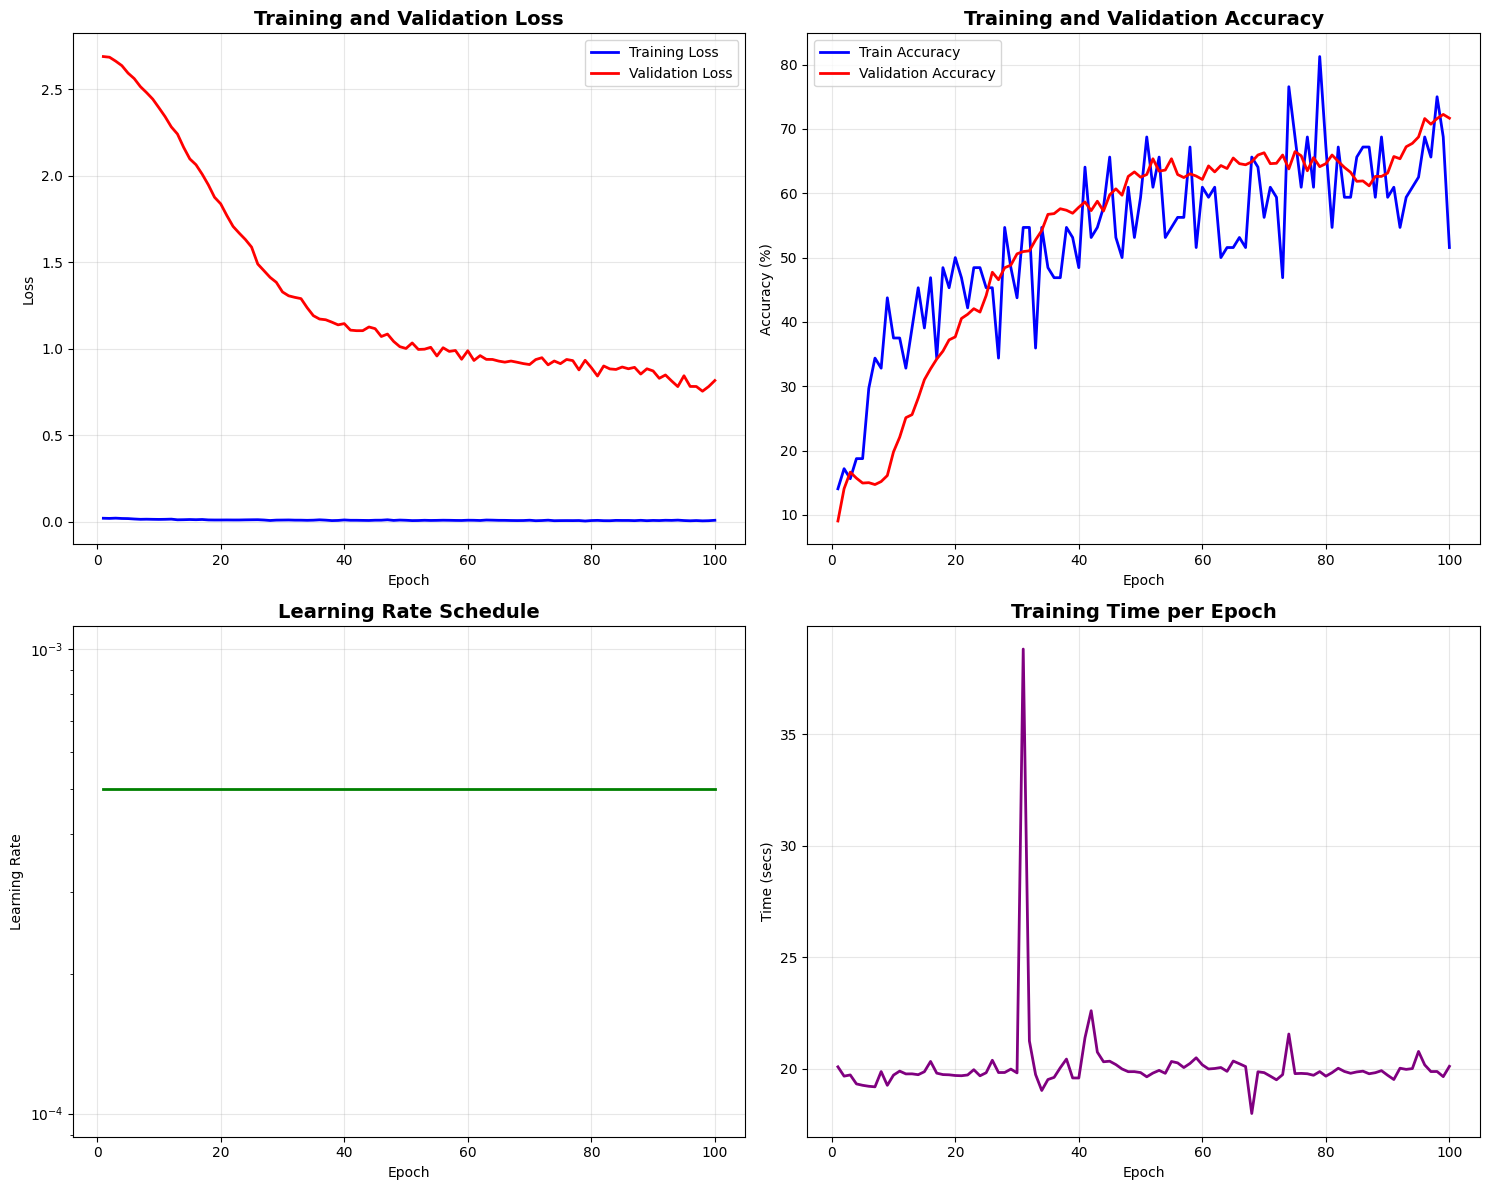

Running final evaluation...


Epoch 0/1 [TEST]: 100%|██████████| 54/54 [00:05<00:00, 10.69it/s, Loss=0.6473, Acc=70.74%]


Plotting confusion matrix...


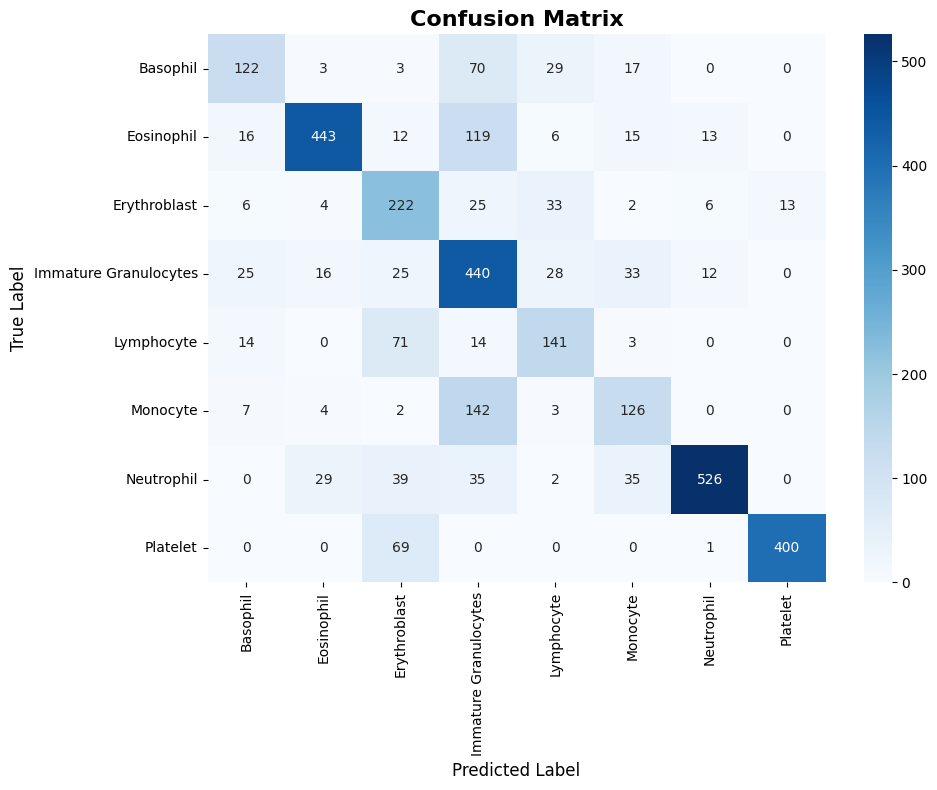


=== DETAILED METRICS ===
Overall Accuracy: 0.7074  (70.74%)

Per-Class Accuracy:
 Basophil: 0.5000 (50.00%) [122 / 244]
 Eosinophil: 0.7099 (70.99%) [443 / 624]
 Erythroblast: 0.7138 (71.38%) [222 / 311]
 Immature Granulocytes: 0.7599 (75.99%) [440 / 579]
 Lymphocyte: 0.5802 (58.02%) [141 / 243]
 Monocyte: 0.4437 (44.37%) [126 / 284]
 Neutrophil: 0.7898 (78.98%) [526 / 666]
 Platelet: 0.8511 (85.11%) [400 / 470]

Classification Report:
                       precision    recall  f1-score   support

             Basophil       0.64      0.50      0.56       244
           Eosinophil       0.89      0.71      0.79       624
         Erythroblast       0.50      0.71      0.59       311
Immature Granulocytes       0.52      0.76      0.62       579
           Lymphocyte       0.58      0.58      0.58       243
             Monocyte       0.55      0.44      0.49       284
           Neutrophil       0.94      0.79      0.86       666
             Platelet       0.97      0.85      0.91  

In [31]:
print("=== VERIFICATION ===")
if test_training_setup(model, train_loader, val_loader, class_names):
    print("✅ All checks passed! Ready to train.")
    
    # now train
    trained_model, training_metrics, best_state = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        num_epochs=100,
        device=device,
        class_names=class_names,
        save_model_path='best_bloodmnist_model.pth',
        print_every=1,
        detailed_every=5,
        patience=10,
        min_delta=0.005
    )
    
    # now plot
    print('Plotting training progress...')
    plot_training_progress(training_metrics, save_path='training_progress.png')
    
    # now final evaluation with best model
    print("Running final evaluation...")
    model.load_state_dict(best_state)
    test_loss, test_acc, all_pred, all_targets, class_correct, class_total = evaluate(
    model, test_loader, criterion, device, -1, 1, mode='TEST')
    
    # now plotting the confusion matrix
    print("Plotting confusion matrix...")
    plot_confusion_matrix(all_targets, all_pred, class_names, save_path='confusion_matrix.png')
    
    # printing final detailed metrics
    detailed_metrics(all_pred, all_targets, class_correct, class_total, class_names)
else: 
    print("❌ Setup verification failed. Please check your dataset and class names.")